In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

C:\Users\pouss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
C:\Users\pouss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

csv_file = os.path.join(path, "mnist_test.csv")

df = pd.read_csv(csv_file)
data = df.drop('label', axis=1).values

dataset = torch.tensor(data).float()
dataset = (dataset - 127.5) / 127.5

dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)


In [ ]:

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256), 
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 784),
            nn.Tanh() 
        )
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3), 
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)


In [ ]:

gen = Generator()
disc = Discriminator()
criterion = nn.BCELoss()


In [ ]:

opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 6

Discriminator Accuracy: 95.00%


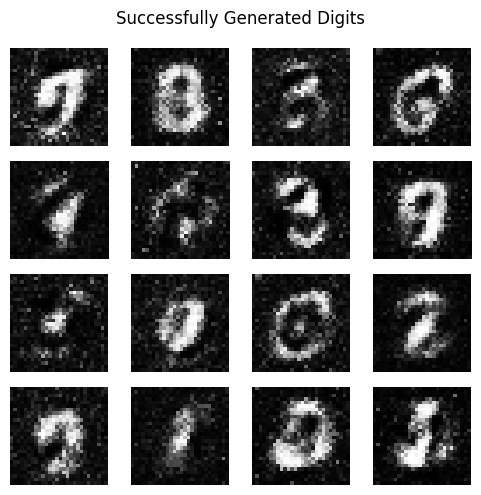

In [ ]:


for epoch in range(epochs):
    for i, real_batch in enumerate(dataloader):
        batch_size = real_batch.size(0)
        
        
        opt_d.zero_grad()
        real_labels = torch.ones(batch_size, 1) * 0.9
        fake_labels = torch.zeros(batch_size, 1)
        
        real_loss = criterion(disc(real_batch), real_labels)
        
        noise = torch.randn(batch_size, 100)
        fake_batch = gen(noise)
        fake_loss = criterion(disc(fake_batch.detach()), fake_labels)
        
        d_loss = real_loss + fake_loss
        d_loss.backward()
        opt_d.step()
        

        opt_g.zero_grad()
        g_loss = criterion(disc(fake_batch), torch.ones(batch_size, 1))
        g_loss.backward()
        opt_g.step()
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] complete.")


test_noise = torch.randn(16, 100)
generated_images = gen(test_noise).detach().view(-1, 28, 28)

final_acc = (disc(gen(torch.randn(100, 100))) < 0.5).float().mean()
print(f"Discriminator Accuracy: {final_acc.item() * 100:.2f}%")



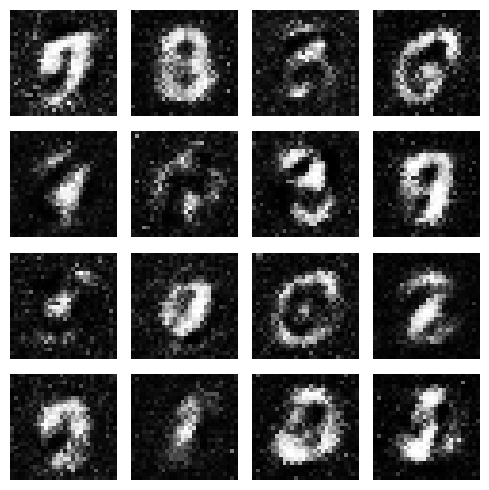

In [8]:


fig, axes = plt.subplots(4, 4, figsize=(5, 5))
for i, ax in enumerate(axes.flatten()):
 
    img = generated_images[i] * 0.5 + 0.5 
    ax.imshow(img.numpy(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()